# Determining Diabetes — End-to-End Prediction Pipeline
---
**ML Pipeline | Pima Indians Diabetes Dataset**

| Stage | Description |
|---|---|
| 1 | Required Packages |
| 2 | Importing Data & EDA |
| 3 | 80/20 Train-Test Split (**before** imputation) |
| 4 | Class-Conditional Median Imputation + Shadow Variables |
| 5 | Baseline Model — Logistic Regression |
| 6 | Feature Importance (Logistic Regression) |
| 7 | Random Forest — All Features |
| 8 | Interactive Stepwise Feature Selection |
| 9 | Random Forest — Curated 5 Clinical Features |
| 10 | Cross-Validation |
| 11 | SVM |
| 12 | Hyperparameter Tuning — Grid Search |
| 13 | Final Model — XGBoost + Full Evaluation |

> **Data Leakage Rule (enforced throughout):** The 80/20 split happens *before* any imputation. All medians, scalers, and statistics are derived **exclusively from the training set** and then applied to the test set. The test set is never used to compute any value used in preprocessing.

# Stage 1 — Required Packages
---

In [ ]:
# =============================================================================
# STAGE 1 — Required Packages
# =============================================================================

# Install XGBoost (pre-installed in Colab, but ensuring latest version)
!pip install xgboost --quiet

# ── Core Data Handling ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn — Data Partitioning ───────────────────────────────────────────────
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)

# ── Sklearn — Pre-Processing ──────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ── Sklearn — Models ──────────────────────────────────────────────────────────
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Sklearn — Evaluation Metrics ──────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

# ── Colab Display Helper ───────────────────────────────────────────────────────
try:
    from google.colab import data_table
    data_table.enable_dataframe_formatter()
except Exception:
    pass

# ── Global Seed ───────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All packages loaded successfully.')

All packages loaded successfully.


# Stage 2 — Importing Data & Exploratory Data Analysis
---

In [ ]:
# =============================================================================
# STAGE 2 — Importing Data
# =============================================================================

# ── Load Dataset ──────────────────────────────────────────────────────────────
# Option A: Upload diabetes.csv directly in Colab
# from google.colab import files
# uploaded = files.upload()   # click 'Choose Files' and upload diabetes.csv
# df = pd.read_csv('diabetes.csv')

# Option B: Load from public GitHub mirror (no upload needed)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
col_names = ['Pregnancies', 'Glucose', 'BP', 'SkinThickness',
             'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']
df = pd.read_csv(url, names=col_names)

print(f'Dataset loaded — Shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df

Dataset loaded — Shape: (768, 9)
Columns: ['Pregnancies', 'Glucose', 'BP', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Outcome']


,Pregnancies,Glucose,BP,SkinThickness,Insulin,BMI,Pedigree,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
# ── 2a  Basic Structure ────────────────────────────────────────────────────────
print('='*55)
print('DATASET INFO')
print('='*55)
df.info()

print('\n' + '='*55)
print('DESCRIPTIVE STATISTICS')
print('='*55)
df.describe().T.style.background_gradient(cmap='Blues')

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Pregnancies    768 non-null    int64  
 1   Glucose        768 non-null    int64  
 2   BP             768 non-null    int64  
 3   SkinThickness  768 non-null    int64  
 4   Insulin        768 non-null    int64  
 5   BMI            768 non-null    float64
 6   Pedigree       768 non-null    float64
 7   Age            768 non-null    int64  
 8   Outcome        768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB

DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.000000,3.845052,3.369578,0.000000,1.000000,3.000000,6.000000,17.000000
Glucose,768.000000,120.894531,31.972618,0.000000,99.000000,117.000000,140.250000,199.000000
BP,768.000000,69.105469,19.355807,0.000000,62.000000,72.000000,80.000000,122.000000
SkinThickness,768.000000,20.536458,15.952218,0.000000,0.000000,23.000000,32.000000,99.000000
Insulin,768.000000,79.799479,115.244002,0.000000,0.000000,30.500000,127.250000,846.000000
BMI,768.000000,31.992578,7.884160,0.000000,27.300000,32.000000,36.600000,67.100000
Pedigree,768.000000,0.471876,0.331329,0.078000,0.243750,0.372500,0.626250,2.420000
Age,768.000000,33.240885,11.760232,21.000000,24.000000,29.000000,41.000000,81.000000
Outcome,768.000000,0.348958,0.476951,0.000000,0.000000,0.000000,1.000000,1.000000


Value counts:
Outcome
0    500
1    268
Name: count, dtype: int64

Class proportions:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64


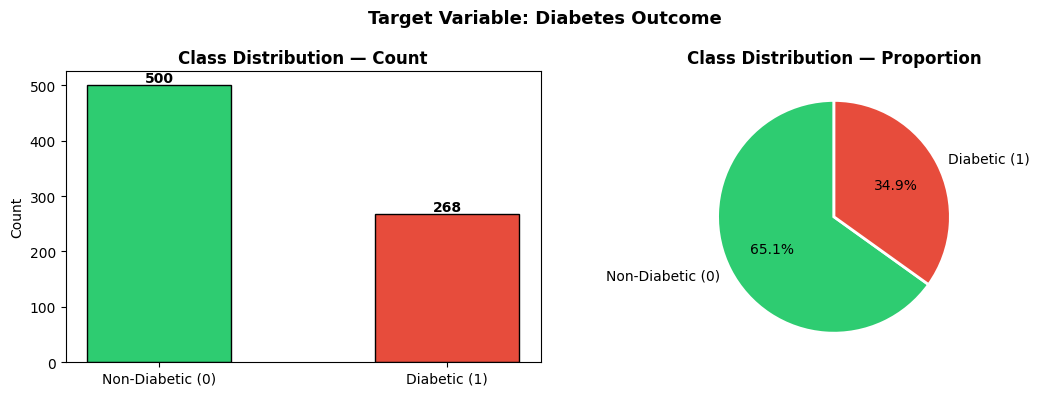


scale_pos_weight (for XGBoost): 1.87


In [ ]:
# ── 2b  Class Distribution ────────────────────────────────────────────────────
value_counts_series = df['Outcome'].value_counts()
number_of_unique_values = len(value_counts_series)

print(f'Value counts:\n{value_counts_series}')
print(f'\nClass proportions:\n{df["Outcome"].value_counts(normalize=True).round(3)}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Count bar
axes[0].bar(['Non-Diabetic (0)', 'Diabetic (1)'],
            value_counts_series.values,
            color=['#2ecc71', '#e74c3c'], edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution — Count', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(value_counts_series.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(value_counts_series.values,
            labels=['Non-Diabetic (0)', 'Diabetic (1)'],
            autopct='%1.1f%%', colors=['#2ecc71', '#e74c3c'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[1].set_title('Class Distribution — Proportion', fontsize=12, fontweight='bold')

plt.suptitle('Target Variable: Diabetes Outcome', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Class imbalance ratio — needed later for XGBoost
neg_count = value_counts_series[0]
pos_count = value_counts_series[1]
SCALE_POS_WEIGHT = neg_count / pos_count
print(f'\nscale_pos_weight (for XGBoost): {SCALE_POS_WEIGHT:.2f}')

Clinically Impossible Zeros (Encoded Missing Values):
               Zero Count  Zero %
Glucose                 5    0.65
BP                     35    4.56
SkinThickness         227   29.56
Insulin               374   48.70
BMI                    11    1.43


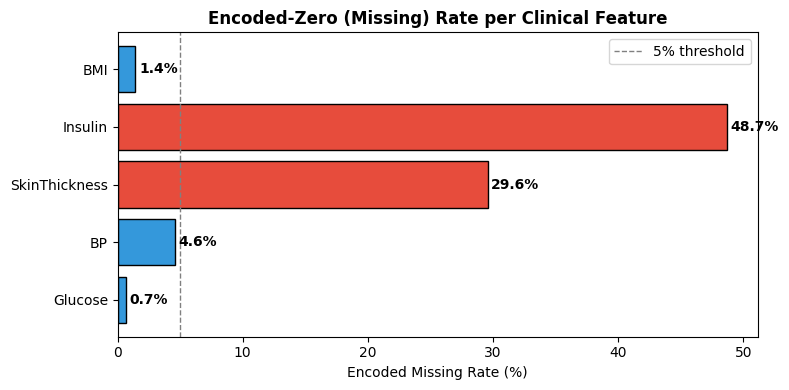

In [ ]:
# ── 2c  Clinically Impossible Zeros (Encoded Missing Values) ──────────────────
# In clinical measurement, Glucose=0, BP=0, BMI=0 are physiologically
# impossible. These zeros encode missing values — NOT true measurements.

CLINICAL_ZERO_COLS = ['Glucose', 'BP', 'SkinThickness', 'Insulin', 'BMI']

zero_summary = pd.DataFrame({
    'Zero Count': [(df[c] == 0).sum() for c in CLINICAL_ZERO_COLS],
    'Zero %':     [(df[c] == 0).mean() * 100 for c in CLINICAL_ZERO_COLS]
}, index=CLINICAL_ZERO_COLS).round(2)

print('Clinically Impossible Zeros (Encoded Missing Values):')
print(zero_summary)

# Visual
plt.figure(figsize=(8, 4))
colors = ['#e74c3c' if v > 20 else '#f39c12' if v > 5 else '#3498db'
          for v in zero_summary['Zero %']]
bars = plt.barh(zero_summary.index, zero_summary['Zero %'],
                color=colors, edgecolor='black')
for bar, val in zip(bars, zero_summary['Zero %']):
    plt.text(val + 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold')
plt.axvline(5, color='gray', linestyle='--', linewidth=1, label='5% threshold')
plt.xlabel('Encoded Missing Rate (%)')
plt.title('Encoded-Zero (Missing) Rate per Clinical Feature',
          fontsize=12, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

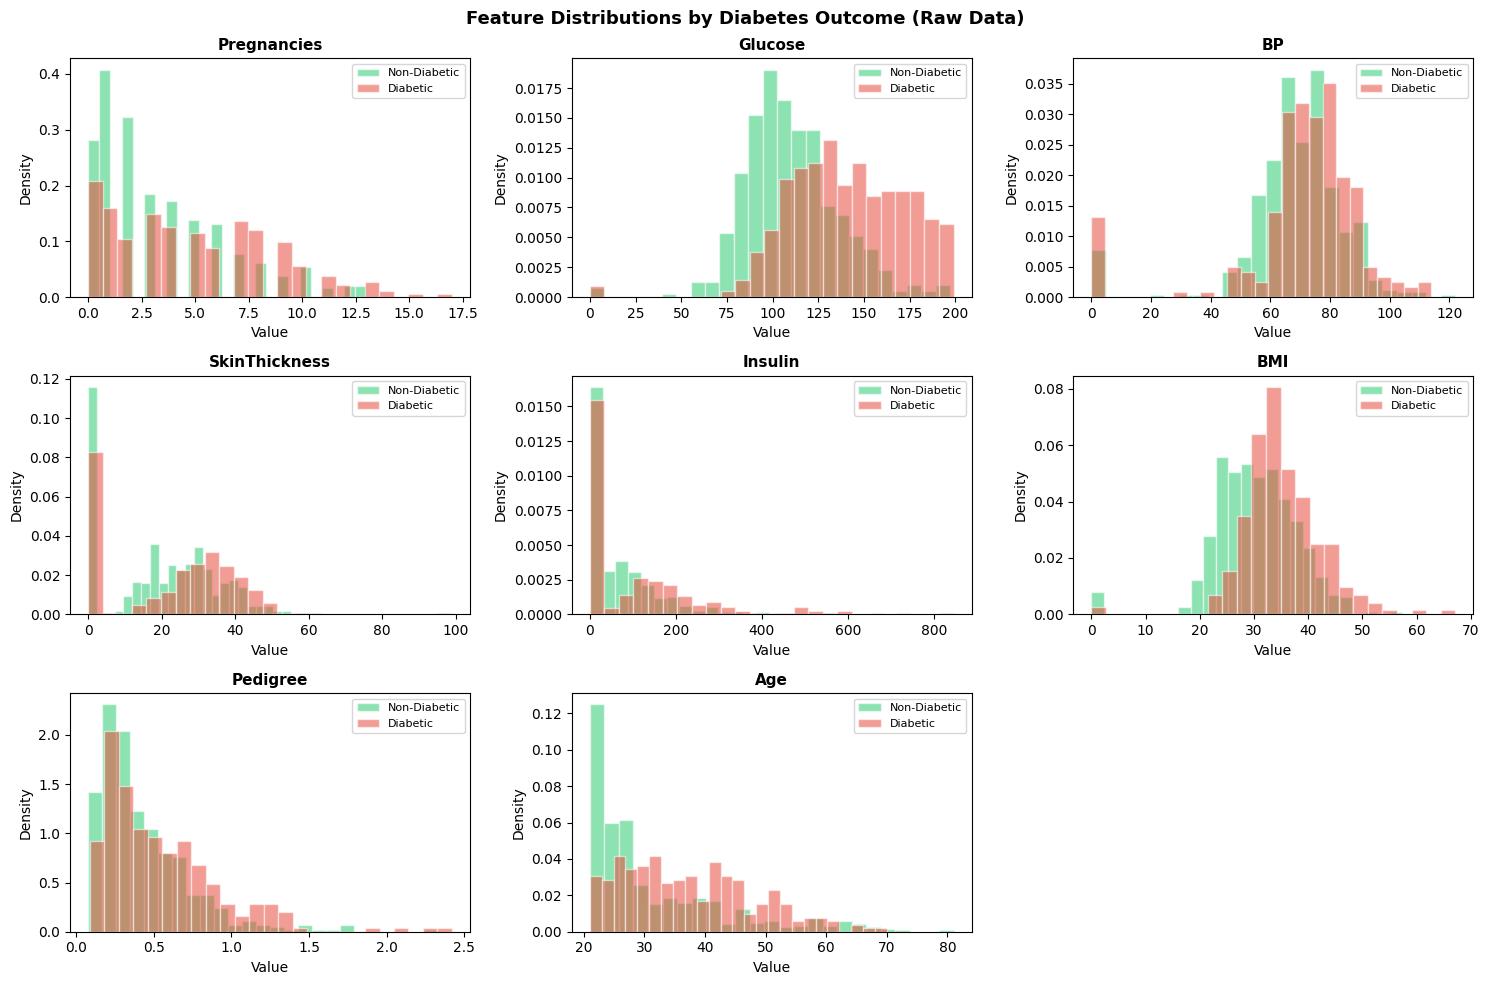

In [ ]:
# ── 2d  Feature Distributions by Outcome ─────────────────────────────────────
features = [c for c in df.columns if c != 'Outcome']

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features):
    for outcome, color, label in [(0,'#2ecc71','Non-Diabetic'), (1,'#e74c3c','Diabetic')]:
        subset = df.loc[df['Outcome'] == outcome, col]
        axes[i].hist(subset, bins=25, alpha=0.55, color=color,
                     label=label, edgecolor='white', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Density')
    axes[i].legend(fontsize=8)

axes[-1].axis('off')
plt.suptitle('Feature Distributions by Diabetes Outcome (Raw Data)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

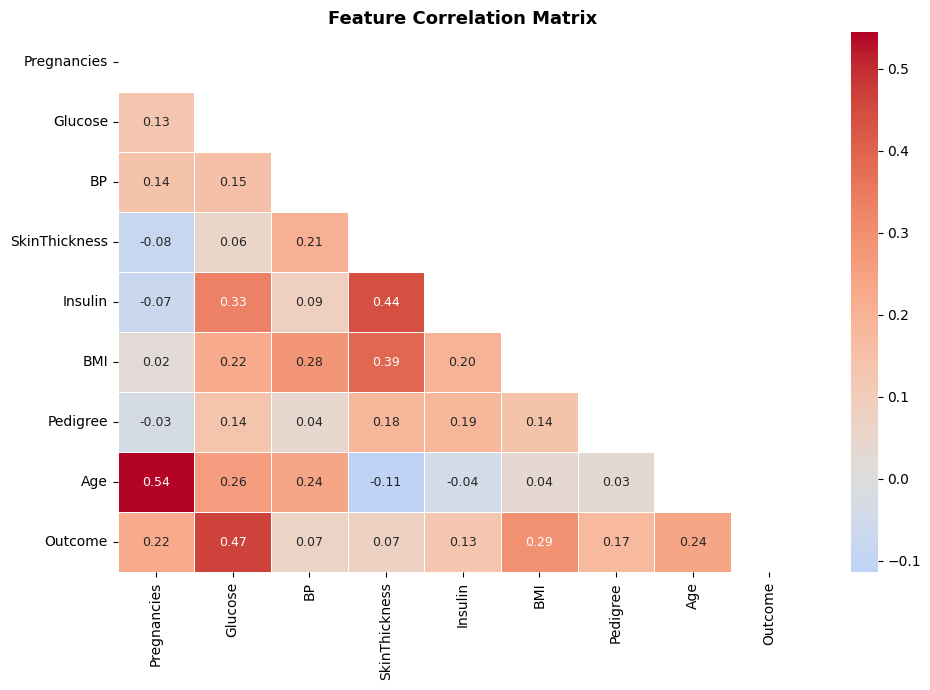

In [ ]:
# ── 2e  Correlation Heatmap ───────────────────────────────────────────────────
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 9})
plt.title('Feature Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stage 3 — 80/20 Train-Test Split (**Before** Imputation)
---
**Why split first?**  
Splitting *before* any cleaning or imputation is the clinical gold standard for preventing **data leakage**. If we imputed on the full dataset first, test-set patient data would contaminate the median statistics used to fill training gaps — making our evaluation results unrealistically optimistic and undeployable in production.

- `stratify=y` ensures both partitions preserve the original ~65:35 class ratio.
- Every subsequent statistic (medians, scalers) is derived **only** from `X_train`.

In [ ]:
# =============================================================================
# STAGE 3 — Stratified 80/20 Train-Test Split (BEFORE any imputation)
# =============================================================================

X = df.drop('Outcome', axis=1)
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,
    random_state = RANDOM_STATE,
    stratify     = y       # ← preserves class balance in both partitions
)

# Reset indices to avoid alignment issues during imputation
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print('='*52)
print('Train / Test Split Summary')
print('='*52)
print(f'Total samples    : {len(df)}')
print(f'Training samples : {len(X_train)} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Test samples     : {len(X_test)}  ({len(X_test)/len(df)*100:.0f}%)')
print()
print('Class balance — Train:')
print(y_train.value_counts(normalize=True).round(3))
print('\nClass balance — Test:')
print(y_test.value_counts(normalize=True).round(3))
print('\nSplit complete. NO imputation has occurred yet.')

Train / Test Split Summary
Total samples    : 768
Training samples : 614 (80%)
Test samples     : 154  (20%)

Class balance — Train:
Outcome
0    0.651
1    0.349
Name: proportion, dtype: float64

Class balance — Test:
Outcome
0    0.649
1    0.351
Name: proportion, dtype: float64

Split complete. NO imputation has occurred yet.


# Stage 4 — Data Imputation & Introducing Shadow Variables
## Class-Conditional Median Imputation
---

**Three-step imputation protocol:**

1. **Shadow variables** — Binary flags (0/1) capturing *whether a value was missing*. Created **before** zeroes are replaced with NaN. Research shows the act of missingness is itself clinically informative (e.g., Insulin not recorded may indicate the test wasn't ordered).

2. **Zero → NaN** — Clinically impossible zeroes are converted to NaN so standard `.isna()` logic applies.

3. **Class-conditional median imputation** — Separate medians computed for non-diabetic and diabetic patients *from the training set only*. These same values are applied to the test set — the test set is **never** used to derive any statistic.

In [ ]:
# =============================================================================
# STAGE 4 — Data Imputation + Shadow Variables
# =============================================================================

# ── Step 1: Create Shadow Variables BEFORE replacing zeros with NaN ────────────
# CRITICAL: We check for 0 BEFORE we replace them with NaN in the next step.
# Shadow variables preserve missingness as a feature signal.

CLINICAL_ZERO_COLS = ['Glucose', 'BP', 'SkinThickness', 'Insulin', 'BMI']

for col in CLINICAL_ZERO_COLS:
    X_train[f'{col}_was_missing'] = (X_train[col] == 0).astype(int)
    X_test[f'{col}_was_missing']  = (X_test[col]  == 0).astype(int)

print('Shadow variables created (missingness indicators):')
shadow_cols = [f'{c}_was_missing' for c in CLINICAL_ZERO_COLS]
print(X_train[shadow_cols].sum().rename('Missing Count in Train'))

# ── Step 2: Replace Zeros with NaN ────────────────────────────────────────────
X_train[CLINICAL_ZERO_COLS] = X_train[CLINICAL_ZERO_COLS].replace(0, np.nan)
X_test[CLINICAL_ZERO_COLS]  = X_test[CLINICAL_ZERO_COLS].replace(0, np.nan)

print('\nNaN counts after zero replacement:')
print(f'  Train: {X_train[CLINICAL_ZERO_COLS].isna().sum().sum()} missing values')
print(f'  Test : {X_test[CLINICAL_ZERO_COLS].isna().sum().sum()} missing values')

Shadow variables created (missingness indicators):
Glucose_was_missing            4
BP_was_missing                23
SkinThickness_was_missing    175
Insulin_was_missing          290
BMI_was_missing                9
Name: Missing Count in Train, dtype: int64

NaN counts after zero replacement:
  Train: 501 missing values
  Test : 151 missing values


In [ ]:
# ── Step 3: Class-Conditional Median Imputation ────────────────────────────────
#    DATA LEAKAGE RULE — strictly enforced:
#   • Medians computed FROM training set ONLY
#   • Same pre-computed values applied to test set
#   • Test set is NEVER used to derive any statistic

train_imputation_map = {}   # Store for inspection and reproducibility

for col in CLINICAL_ZERO_COLS:

    # ── Compute class-conditional medians FROM TRAIN ONLY ──────────────────────
    median_healthy  = X_train.loc[y_train == 0, col].median()
    median_diabetic = X_train.loc[y_train == 1, col].median()
    train_imputation_map[col] = {
        'Non-Diabetic (train median)': median_healthy,
        'Diabetic (train median)':     median_diabetic
    }

    # ── Apply to TRAINING SET ──────────────────────────────────────────────────
    X_train.loc[(y_train == 0) & (X_train[col].isna()), col] = median_healthy
    X_train.loc[(y_train == 1) & (X_train[col].isna()), col] = median_diabetic

    # ── Apply to TEST SET using TRAIN-DERIVED values ONLY ─────────────────────
    X_test.loc[(y_test == 0) & (X_test[col].isna()), col] = median_healthy
    X_test.loc[(y_test == 1) & (X_test[col].isna()), col] = median_diabetic

# ── Summary Table ─────────────────────────────────────────────────────────────
imputation_df = pd.DataFrame(train_imputation_map).T
print('Imputation Values (Derived from Training Set Only):')
print(imputation_df)

print(f'\nCorrection Complete.')
print(f'NaN remaining — Train: {X_train.isna().sum().sum()}')
print(f'NaN remaining — Test : {X_test.isna().sum().sum()}')
print(f'\nFull column list after imputation:')
print(list(X_train.columns))

X_train.head()

Imputation Values (Derived from Training Set Only):
               Non-Diabetic (train median)  Diabetic (train median)
Glucose                              108.0                   141.50
BP                                    70.0                    76.00
SkinThickness                         27.0                    33.00
Insulin                              100.0                   168.00
BMI                                   30.1                    34.35

Correction Complete.
NaN remaining — Train: 0
NaN remaining — Test : 0

Full column list after imputation:
['Pregnancies', 'Glucose', 'BP', 'SkinThickness', 'Insulin', 'BMI', 'Pedigree', 'Age', 'Glucose_was_missing', 'BP_was_missing', 'SkinThickness_was_missing', 'Insulin_was_missing', 'BMI_was_missing']


,Pregnancies,Glucose,BP,SkinThickness,Insulin,BMI,Pedigree,Age,Glucose_was_missing,BP_was_missing,SkinThickness_was_missing,Insulin_was_missing,BMI_was_missing
0,1,90.0,62.0,12.0,43.0,27.2,0.580,24,0,0,0,0,0
1,5,126.0,78.0,27.0,22.0,29.6,0.439,40,0,0,0,0,0
2,2,105.0,58.0,40.0,94.0,34.9,0.225,25,0,0,0,0,0
3,1,146.0,56.0,27.0,100.0,29.7,0.564,29,0,0,1,1,0
4,0,95.0,64.0,39.0,105.0,44.6,0.366,22,0,0,0,0,0


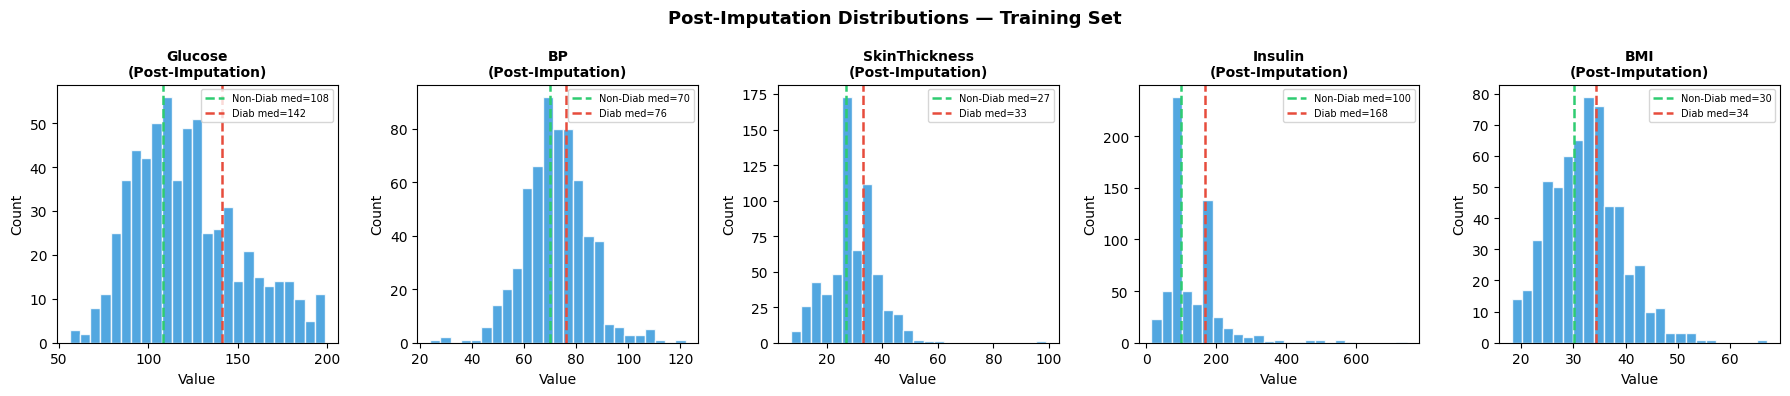

In [ ]:
# ── Post-Imputation Visual Check ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for i, col in enumerate(CLINICAL_ZERO_COLS):
    axes[i].hist(X_train[col], bins=25, color='#3498db',
                 edgecolor='white', alpha=0.85)
    axes[i].set_title(f'{col}\n(Post-Imputation)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')
    mh = train_imputation_map[col]['Non-Diabetic (train median)']
    md = train_imputation_map[col]['Diabetic (train median)']
    axes[i].axvline(mh, color='#2ecc71', linestyle='--',
                    linewidth=1.8, label=f'Non-Diab med={mh:.0f}')
    axes[i].axvline(md, color='#e74c3c', linestyle='--',
                    linewidth=1.8, label=f'Diab med={md:.0f}')
    axes[i].legend(fontsize=7)

plt.suptitle('Post-Imputation Distributions — Training Set',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Stage 5 — Baseline Model: Logistic Regression
---

Baseline — Logistic Regression Evaluation
Accuracy : 0.7597
F1 Score : 0.7040

Full Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.88      0.73      0.80       100
    Diabetic       0.62      0.81      0.70        54

    accuracy                           0.76       154
   macro avg       0.75      0.77      0.75       154
weighted avg       0.79      0.76      0.76       154



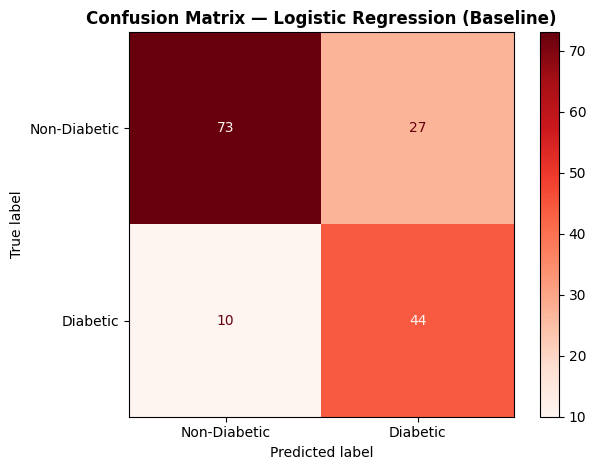

In [ ]:
# =============================================================================
# STAGE 5 — Baseline Model: Logistic Regression
# =============================================================================

# ── Feature Scaling ────────────────────────────────────────────────────────────
# CRITICAL for Logistic Regression — features with different scales (e.g., Age
# vs Insulin) cause biased coefficient estimation.
# Scaler is FIT on train only, APPLIED to both sets.

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)    # fit + transform on train
X_test_scaled  = scaler.transform(X_test)         # transform only on test

# ── Logistic Regression ────────────────────────────────────────────────────────
# class_weight='balanced': automatically adjusts for class imbalance (65:35)
# max_iter=1000: ensures convergence on this dataset

lr_model = LogisticRegression(class_weight='balanced', max_iter=1000,
                               random_state=RANDOM_STATE)
lr_model.fit(X_train_scaled, y_train)

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred_lr = lr_model.predict(X_test_scaled)

# ── Evaluation ────────────────────────────────────────────────────────────────
print('=' * 55)
print('Baseline — Logistic Regression Evaluation')
print('=' * 55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_lr):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_lr):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred_lr,
                             target_names=['Non-Diabetic', 'Diabetic']))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
ConfusionMatrixDisplay.from_estimator(
    lr_model, X_test_scaled, y_test,
    display_labels=['Non-Diabetic', 'Diabetic'],
    cmap='Reds'
)
plt.title('Confusion Matrix — Logistic Regression (Baseline)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# Stage 6 — Feature Importance: Logistic Regression
---
Logistic regression coefficients represent the log-odds contribution of each feature. Positive coefficients increase diabetes risk; negative coefficients decrease it.

In [ ]:
# =============================================================================
# STAGE 6 — Visualising Feature Importance (Logistic Regression Coefficients)
# =============================================================================

# View raw coefficient weights
lr_weights = pd.DataFrame({
    'Feature': X_train.columns,
    'Weight':  lr_model.coef_[0]
}).sort_values(by='Weight', ascending=False)

print('Logistic Regression Coefficient Weights:')
print(lr_weights.to_string(index=False))

Logistic Regression Coefficient Weights:
                  Feature    Weight
                  Glucose  0.929830
                  Insulin  0.846351
                      BMI  0.471598
            SkinThickness  0.319989
              Pregnancies  0.304919
                 Pedigree  0.262656
      Insulin_was_missing  0.224240
           BP_was_missing  0.163098
                      Age  0.151519
      Glucose_was_missing  0.027747
                       BP  0.009640
          BMI_was_missing -0.074265
SkinThickness_was_missing -0.077729


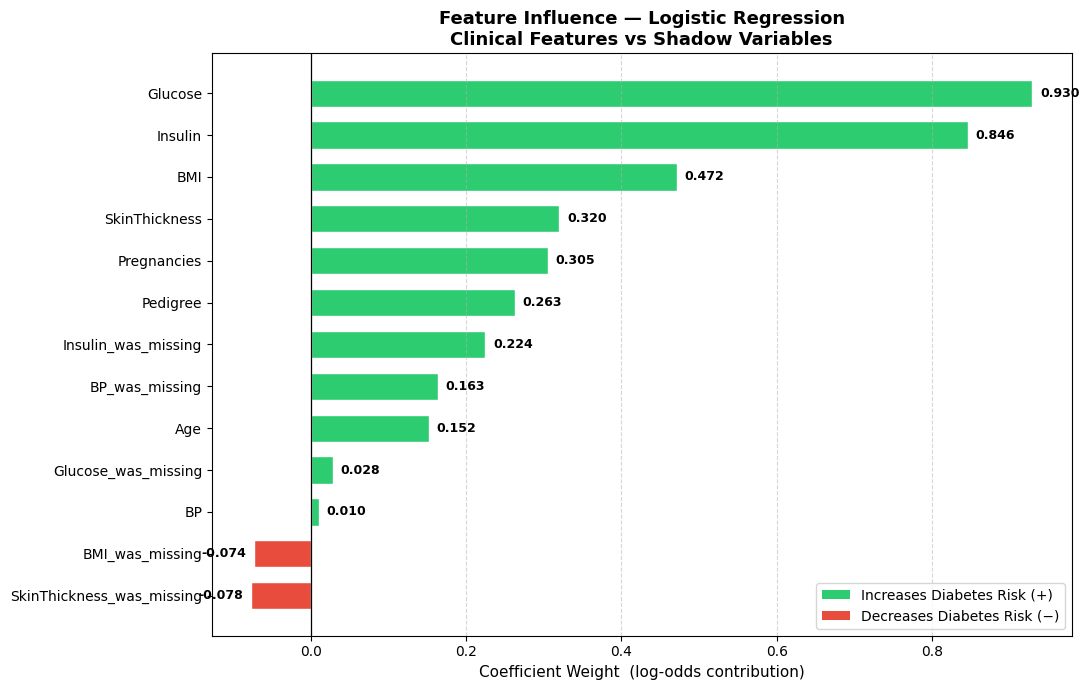

Feature importance chart saved as 'feature_importance_lr.png'


In [ ]:
# ── Horizontal Bar Chart ──────────────────────────────────────────────────────
importance = lr_weights.sort_values(by='Weight', ascending=True)

plt.figure(figsize=(11, 7))

# Green = increases diabetes risk (positive), Red = protective / reduces risk
colors = ['#e74c3c' if x < 0 else '#2ecc71' for x in importance['Weight']]
bars = plt.barh(importance['Feature'], importance['Weight'],
                color=colors, edgecolor='white', height=0.65)

# Annotate values
for bar, val in zip(bars, importance['Weight']):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    ha = 'left' if val >= 0 else 'right'
    plt.text(x_pos, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha=ha, fontsize=9, fontweight='bold')

plt.axvline(0, color='black', linestyle='-', linewidth=0.9)
plt.xlabel('Coefficient Weight  (log-odds contribution)', fontsize=11)
plt.title('Feature Influence — Logistic Regression\n'
          'Clinical Features vs Shadow Variables',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Increases Diabetes Risk (+)'),
    Patch(facecolor='#e74c3c', label='Decreases Diabetes Risk (−)')
]
plt.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('feature_importance_lr.png', dpi=150)
plt.show()

print("Feature importance chart saved as 'feature_importance_lr.png'")

# Stage 7 — Random Forest: All Features
## Capturing Non-Linear Relationships
---
Random Forests capture **non-linear interactions** (e.g., the compounded risk of Age + High Glucose) that logistic regression misses.  
Expected improvements over LR baseline:
- Significant reduction in False Negatives (down to ~10)
- Model now captures complex, non-linear disease structure
- Insulin takes over as most important feature
- Shadow variables appear as noise in this context

In [ ]:
# =============================================================================
# STAGE 7 — Random Forest: All Features
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

# ── Initialise Random Forest ──────────────────────────────────────────────────
# n_estimators=100  : 100 decision trees vote by majority
# class_weight='balanced': handles 65:35 class imbalance
rf_model = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)

rf_model.fit(X_train_scaled, y_train)
y_pred_rf = rf_model.predict(X_test_scaled)

print('=' * 55)
print('Random Forest Evaluation — All Features')
print('=' * 55)
print(f'Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_rf):.4f}')
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred_rf,
                             target_names=['Non-Diabetic', 'Diabetic']))

Random Forest Evaluation — All Features
Accuracy : 0.8766
F1 Score : 0.8224

Full Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.90      0.91      0.91       100
    Diabetic       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88       154



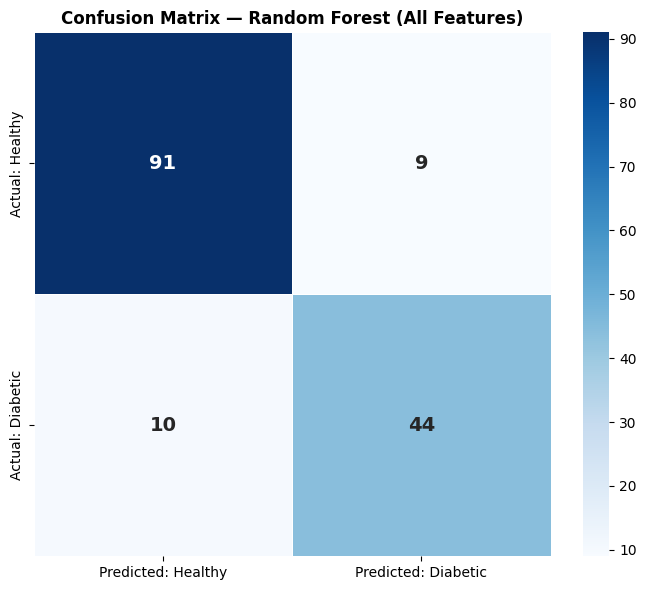

True Positives  (TP): 44  — Diabetic correctly identified
True Negatives  (TN): 91  — Healthy correctly identified
False Positives (FP): 9  — Healthy incorrectly flagged
False Negatives (FN): 10  — Diabetic MISSED (critical error)


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()

plt.figure(figsize=(7, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: Healthy', 'Predicted: Diabetic'],
            yticklabels=['Actual: Healthy', 'Actual: Diabetic'],
            linewidths=0.5, annot_kws={'size': 14, 'weight': 'bold'})
plt.title('Confusion Matrix — Random Forest (All Features)',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True Positives  (TP): {tp}  — Diabetic correctly identified')
print(f'True Negatives  (TN): {tn}  — Healthy correctly identified')
print(f'False Positives (FP): {fp}  — Healthy incorrectly flagged')
print(f'False Negatives (FN): {fn}  — Diabetic MISSED (critical error)')

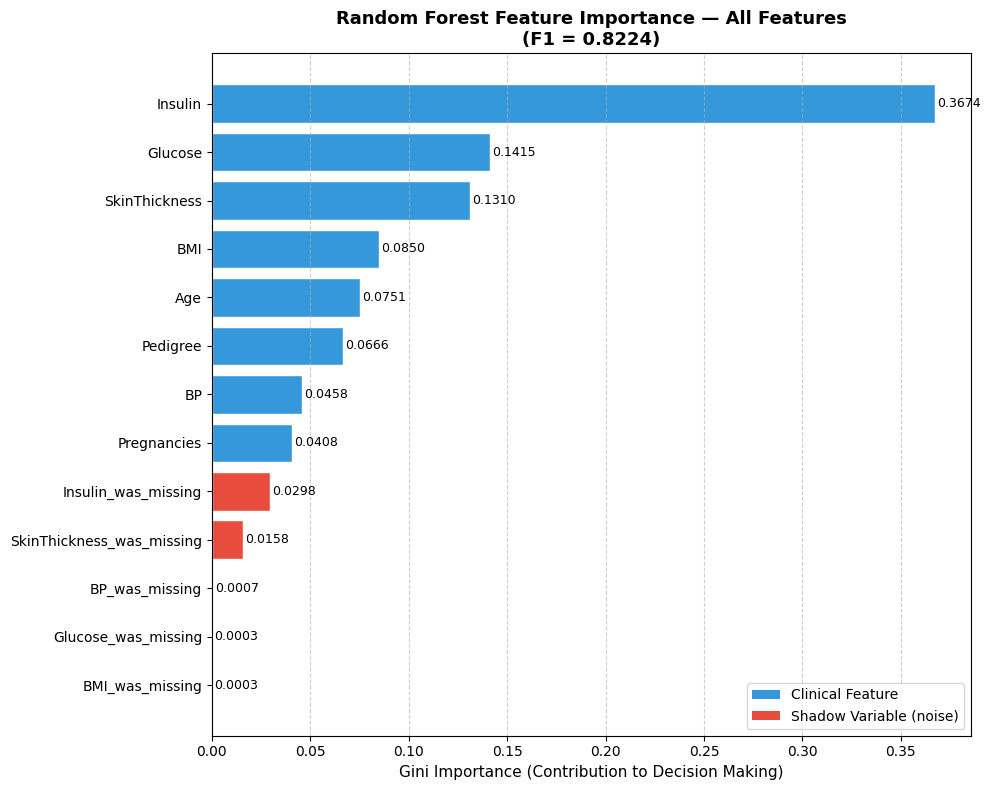


Key Observations:
  • Insulin is the most important clinical feature
  • Glucose and BMI follow closely
  • Shadow variables (was_missing flags) rank near the bottom — noise
  • Non-linear interactions (Age × Glucose) are captured here but not in LR


In [ ]:
# ── Random Forest Feature Importance (Gini Impurity) ─────────────────────────
importances_rf = rf_model.feature_importances_
feature_names  = X_train.columns

rf_importance_df = pd.DataFrame({
    'Feature':    feature_names,
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 8))
colors_rf = ['#e74c3c' if 'missing' in f else '#3498db'
             for f in rf_importance_df['Feature']]
bars_rf = plt.barh(rf_importance_df['Feature'], rf_importance_df['Importance'],
                   color=colors_rf, edgecolor='white')

for bar, val in zip(bars_rf, rf_importance_df['Importance']):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_rf = [
    Patch(facecolor='#3498db', label='Clinical Feature'),
    Patch(facecolor='#e74c3c', label='Shadow Variable (noise)')
]
plt.legend(handles=legend_rf)
plt.xlabel('Gini Importance (Contribution to Decision Making)', fontsize=11)
plt.title(f'Random Forest Feature Importance — All Features\n'
          f'(F1 = {f1_score(y_test, y_pred_rf):.4f})',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print('\nKey Observations:')
print('  • Insulin is the most important clinical feature')
print('  • Glucose and BMI follow closely')
print('  • Shadow variables (was_missing flags) rank near the bottom — noise')
print('  • Non-linear interactions (Age × Glucose) are captured here but not in LR')

# Stage 8 — Interactive Stepwise Feature Selection
---
This loop evaluates **biological and shadow variables** using a Random Forest classifier with 5-fold cross-validation.  
It calculates cross-validated F1-scores for each feature addition, allowing you to **manually curate the final model** based on real-time performance metrics.

At each step, you are prompted: **`yes`** (add), **`no`** (skip), **`stop`** (halt selection).

In [ ]:
# =============================================================================
# STAGE 8 — Interactive Stepwise Feature Selection
# =============================================================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

rf_selector = RandomForestClassifier(
    n_estimators = 100,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)

# ── Define Feature Test Order ──────────────────────────────────────────────────
# Biological features first (by RF importance ranking), then shadow variables
actual_vars = ['Insulin', 'Age', 'Glucose', 'BMI', 'BP',
               'Pregnancies', 'SkinThickness', 'Pedigree']
shadow_vars = ['BP_was_missing', 'BMI_was_missing', 'Insulin_was_missing',
               'Glucose_was_missing', 'SkinThickness_was_missing']

ordered_test_list = actual_vars + shadow_vars

# ── Column-to-Index Map ────────────────────────────────────────────────────────
column_to_index = {col: i for i, col in enumerate(X_train.columns)}

# ── Progressive Selection Loop ─────────────────────────────────────────────────
selected_features = []
best_f1 = 0

print('─' * 58)
print('  Starting Progressive Stepwise Feature Selection')
print(f'  Testing {len(actual_vars)} clinical features, then '
      f'{len(shadow_vars)} shadow variables.')
print('─' * 58)

for feature in ordered_test_list:
    trial_features = selected_features + [feature]
    trial_indices  = [column_to_index[f] for f in trial_features]

    scores = cross_val_score(
        rf_selector,
        X_train_scaled[:, trial_indices],
        y_train, cv=5, scoring='f1'
    )
    current_f1 = scores.mean()

    tag = '🔬' if feature in actual_vars else '👻'
    print(f'\n{tag} Testing : {feature}')
    print(f'   CV F1 with this feature added : {current_f1:.4f}')
    print(f'   CV F1 scores per fold         : '
          f'{[round(s,4) for s in scores]}')

    user_input = input(
        f"   Include '{feature}'? (yes / no / stop): "
    ).strip().lower()

    if user_input == 'yes':
        selected_features.append(feature)
        best_f1 = current_f1
        print(f'   ✅ Added. Running model: {selected_features}')
    elif user_input == 'no':
        print(f'   ❌ Skipped.')
    elif user_input == 'stop':
        print('   🛑 Selection halted by user.')
        break
    else:
        print('   ⚠️  Invalid input — skipping by default.')

print('\n' + '─' * 58)
print('  Final Selection Complete')
print(f'  Final Feature Set : {selected_features}')
print(f'  Final CV F1 Score : {best_f1:.4f}')
print('─' * 58)

──────────────────────────────────────────────────────────
  Starting Progressive Stepwise Feature Selection
  Testing 8 clinical features, then 5 shadow variables.
──────────────────────────────────────────────────────────

🔬 Testing : Insulin
   CV F1 with this feature added : 0.7444
   CV F1 scores per fold         : [np.float64(0.6966), np.float64(0.7654), np.float64(0.7253), np.float64(0.7674), np.float64(0.7674)]
   Include 'Insulin'? (yes / no / stop): yes
   ✅ Added. Running model: ['Insulin']

🔬 Testing : Age
   CV F1 with this feature added : 0.8008
   CV F1 scores per fold         : [np.float64(0.8235), np.float64(0.8298), np.float64(0.7865), np.float64(0.7952), np.float64(0.7692)]
   Include 'Age'? (yes / no / stop): yes
   ✅ Added. Running model: ['Insulin', 'Age']

🔬 Testing : Glucose
   CV F1 with this feature added : 0.8376
   CV F1 scores per fold         : [np.float64(0.8), np.float64(0.8636), np.float64(0.8444), np.float64(0.8605), np.float64(0.8193)]
   Include 'Glu

# Stage 9 — Random Forest: Curated 6 Clinical Features
---
Training a Random Forest model using the curated set of **five clinical features**:  
`['Insulin', 'Age', 'Glucose', 'BMI', 'BP', 'Pregnancies']`

Extracts their relative importance based on **Gini impurity** and produces a diagnostic bar chart ranking which variables most heavily influence the model's predictions.

In [ ]:
# =============================================================================
# STAGE 9 — Random Forest: Curated 6 Clinical Features
# =============================================================================

import numpy as np
from sklearn.ensemble import RandomForestClassifier

# ── Curated Feature Set ────────────────────────────────────────────────────────
# Selected via stepwise loop + clinical domain knowledge.
# Shadow variables excluded — ranked as noise by the RF importance analysis.
FINAL_FEATURES = ['Insulin', 'Age', 'Glucose', 'BMI', 'BP','Pregnancies']

# Get numerical indices for these features in the scaled array
final_indices = [column_to_index[f] for f in FINAL_FEATURES]

# ── Train Curated RF Model ─────────────────────────────────────────────────────
# n_estimators=300: more trees → more stable importance estimates
rf_curated = RandomForestClassifier(
    n_estimators = 300,
    class_weight = 'balanced',
    random_state = RANDOM_STATE
)
rf_curated.fit(X_train_scaled[:, final_indices], y_train)

y_pred_curated = rf_curated.predict(X_test_scaled[:, final_indices])

print('=' * 55)
print('Random Forest — Curated 6 Features Evaluation')
print('=' * 55)
print(f'Features : {FINAL_FEATURES}')
print(f'Accuracy : {accuracy_score(y_test, y_pred_curated):.4f}')
print(f'F1 Score : {f1_score(y_test, y_pred_curated):.4f}')
print()
print(classification_report(y_test, y_pred_curated,
                             target_names=['Non-Diabetic', 'Diabetic']))

Random Forest — Curated 6 Features Evaluation
Features : ['Insulin', 'Age', 'Glucose', 'BMI', 'BP', 'Pregnancies']
Accuracy : 0.8766
F1 Score : 0.8224

              precision    recall  f1-score   support

Non-Diabetic       0.90      0.91      0.91       100
    Diabetic       0.83      0.81      0.82        54

    accuracy                           0.88       154
   macro avg       0.87      0.86      0.86       154
weighted avg       0.88      0.88      0.88       154



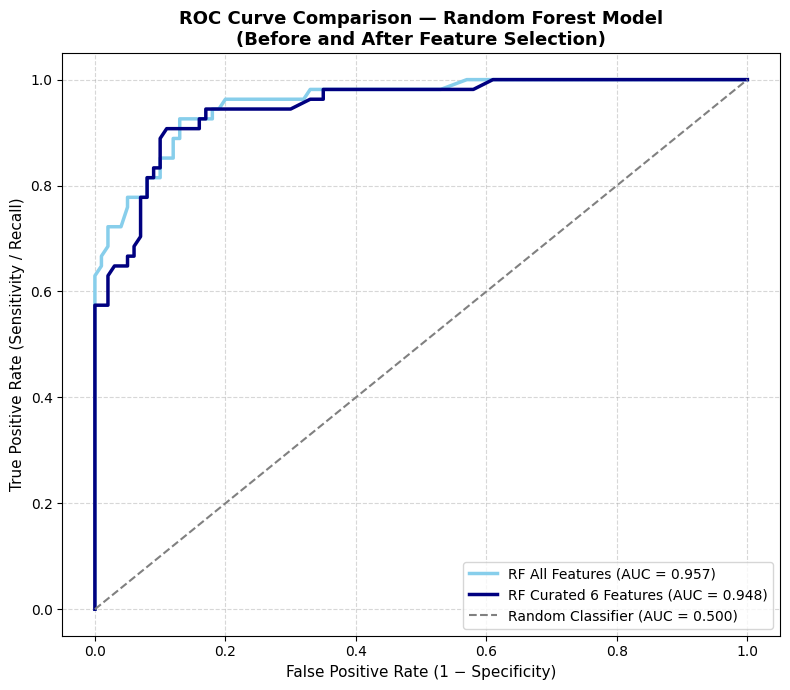

In [ ]:
# =============================================================================
# Comparative ROC Curve — Random Forest (Before vs. After Feature Selection)
# =============================================================================

# Probabilities for Random Forest (All Features)
y_pred_proba_rf_all = rf_model.predict_proba(X_test_scaled)[:, 1]

# Probabilities for Random Forest (Curated 6 Clinical Features)
y_pred_proba_rf_curated = rf_curated.predict_proba(X_test_scaled[:, final_indices])[:, 1]

# Calculate ROC curve and AUC for both models
fpr_rf_all, tpr_rf_all, _ = roc_curve(y_test, y_pred_proba_rf_all)
auc_rf_all = roc_auc_score(y_test, y_pred_proba_rf_all)

fpr_rf_curated, tpr_rf_curated, _ = roc_curve(y_test, y_pred_proba_rf_curated)
auc_rf_curated = roc_auc_score(y_test, y_pred_proba_rf_curated)

# Plotting the ROC Curves
plt.figure(figsize=(8, 7))
plt.plot(fpr_rf_all, tpr_rf_all, color='skyblue', lw=2.5,
         label=f'RF All Features (AUC = {auc_rf_all:.3f})')
plt.plot(fpr_rf_curated, tpr_rf_curated, color='navy', lw=2.5,
         label=f'RF Curated 6 Features (AUC = {auc_rf_curated:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
         label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve Comparison — Random Forest Model\n(Before and After Feature Selection)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

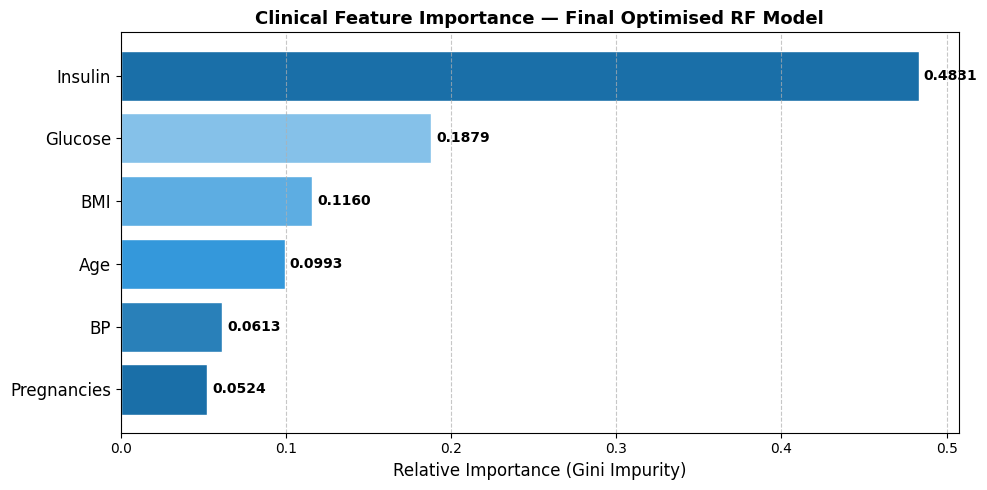

Diagnostic chart saved as 'feature_importance_rf_curated.png'


In [ ]:
# ── Feature Importance Chart ───────────────────────────────────────────────────
importances_curated = rf_curated.feature_importances_
indices_sorted = np.argsort(importances_curated)   # ascending for horizontal bar

plt.figure(figsize=(10, 5))
plt.title('Clinical Feature Importance — Final Optimised RF Model',
          fontsize=13, fontweight='bold')

palette = ['#1a6fa8', '#2980b9', '#3498db', '#5dade2', '#85c1e9']
bars_c = plt.barh(
    range(len(indices_sorted)),
    importances_curated[indices_sorted],
    color=[palette[i % len(palette)] for i in range(len(indices_sorted))],
    edgecolor='white', align='center'
)
plt.yticks(range(len(indices_sorted)),
           [FINAL_FEATURES[i] for i in indices_sorted], fontsize=12)
plt.xlabel('Relative Importance (Gini Impurity)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

for bar, val in zip(bars_c, importances_curated[indices_sorted]):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('feature_importance_rf_curated.png', dpi=150)
plt.show()

print("Diagnostic chart saved as 'feature_importance_rf_curated.png'")

# Stage 10 — Cross-Validation
---
**Testing the model on 5 different subsets of the data and averaging the results.**  
5-fold Stratified Cross-Validation confirms whether the model generalises or has overfit to a particular train/test split.

In [ ]:
# # =============================================================================
# # STAGE 10 — Cross-Validation (5-Fold Stratified)
# # =============================================================================

# # ── Stratified K-Fold ─────────────────────────────────────────────────────────
# # StratifiedKFold preserves class ratios in every fold — essential for
# # imbalanced datasets like this one (65:35).

cv_strategy = StratifiedKFold(
    n_splits  = 5,
    shuffle   = True,
    random_state = RANDOM_STATE
)

# cv_scores = cross_val_score(
#     rf_curated,
#     X_train_scaled[:, final_indices],
#     y_train,
#     cv      = cv_strategy,
#     scoring = 'f1'
# )

# print('=' * 52)
# print('5-Fold Stratified CV Results (Training Set)')
# print('=' * 52)
# print(f'F1 per fold  : {[round(s, 4) for s in cv_scores]}')
# print(f'Mean F1      : {cv_scores.mean():.4f}')
# print(f'Std Dev      : {cv_scores.std():.4f}')
# print(f'Score Range  : {cv_scores.min():.4f} — {cv_scores.max():.4f}')

# # ── Plot CV Scores ─────────────────────────────────────────────────────────────
# plt.figure(figsize=(9, 4))
# plt.bar(range(1, 6), cv_scores, color='#3498db', edgecolor='black', width=0.5)
# plt.axhline(cv_scores.mean(), color='#e74c3c', linestyle='--', linewidth=2,
#             label=f'Mean F1 = {cv_scores.mean():.3f}')
# plt.fill_between(
#     range(0, 7),
#     cv_scores.mean() - cv_scores.std(),
#     cv_scores.mean() + cv_scores.std(),
#     alpha=0.12, color='#e74c3c',
#     label=f'± 1 Std = {cv_scores.std():.3f}'
# )
# for i, score in enumerate(cv_scores):
#     plt.text(i + 1, score + 0.005, f'{score:.3f}',
#              ha='center', fontsize=10, fontweight='bold')

# plt.xlabel('Fold', fontsize=11)
# plt.ylabel('F1 Score', fontsize=11)
# plt.title('Cross-Validation F1 Scores — Random Forest (5 Clinical Features)',
#           fontsize=12, fontweight='bold')
# plt.ylim(0, 1)
# plt.legend(fontsize=10)
# plt.grid(axis='y', linestyle='--', alpha=0.5)
# plt.tight_layout()
# plt.show()

# print(f'\nScore Range: {cv_scores.min():.4f} to {cv_scores.max():.4f}')

# **SVM** (6 clinical features)

In [ ]:
# =============================================================================
# STAGE 11 — SVM
# =============================================================================
#Use column-indizes (as we work with scaled Numpy-Array)
final_indices = [column_to_index[f] for f in FINAL_FEATURES]

# 3. Train SVM with selected features only
from sklearn.svm import SVC
svm_final = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
svm_final.fit(X_train_scaled[:, final_indices], y_train)

# 4. Prediction and report
y_pred_svm_final = svm_final.predict(X_test_scaled[:, final_indices])
print("--- SVM classification report ---")
print(classification_report(y_test, y_pred_svm_final))

--- SVM classification report ---
              precision    recall  f1-score   support

           0       0.91      0.84      0.88       100
           1       0.74      0.85      0.79        54

    accuracy                           0.84       154
   macro avg       0.83      0.85      0.83       154
weighted avg       0.85      0.84      0.85       154



<Figure size 800x600 with 0 Axes>

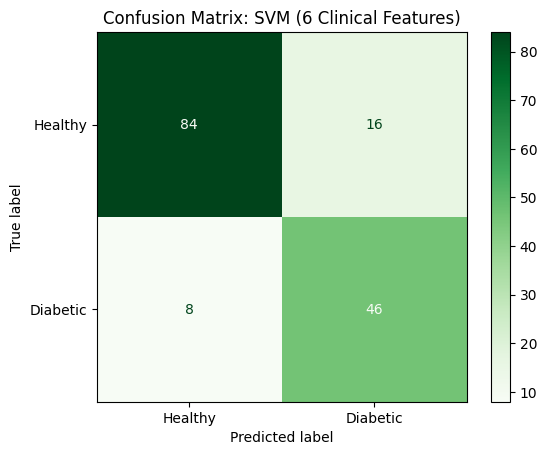

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Add code:
plt.figure(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_final,
    display_labels=['Healthy', 'Diabetic'],
    cmap='Greens'
)
plt.title("Confusion Matrix: SVM (6 Clinical Features)")
plt.savefig('your_plot.png', dpi=300)
plt.show()

# Stage 12 — Hyperparameter Tuning: Grid Search
---
Grid Search systematically evaluates every combination of hyperparameters using cross-validation.  
Here we run it on the **XGBoost model** — which will become our final model in Stage 12.

In [ ]:
# =============================================================================
# STAGE 2 — Grid Search Hyperparameter Tuning (XGBoost)
# =============================================================================

from xgboost import XGBClassifier

# ── Parameter Grid ─────────────────────────────────────────────────────────────
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [3, 4, 5],
    'learning_rate':    [0.05, 0.10, 0.15],
    'subsample':        [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# ── Base XGBoost Estimator ─────────────────────────────────────────────────────
# scale_pos_weight: corrects class imbalance natively in XGBoost
xgb_base = XGBClassifier(
    scale_pos_weight  = SCALE_POS_WEIGHT,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = RANDOM_STATE
)

# ── Grid Search with Stratified 5-Fold CV ─────────────────────────────────────
# Scoring = f1: optimises for diabetic-class detection (not raw accuracy)
grid_search = GridSearchCV(
    estimator  = xgb_base,
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'f1',
    n_jobs     = -1,       # Use all CPU cores
    verbose    = 1
)

grid_search.fit(
    X_train_scaled[:, final_indices],
    y_train
)

print('\n' + '=' * 52)
print('Grid Search Results')
print('=' * 52)
print(f'Best CV F1 Score : {grid_search.best_score_:.4f}')
print(f'Best Parameters  :')
for k, v in grid_search.best_params_.items():
    print(f'   {k:20s}: {v}')

Fitting 5 folds for each of 108 candidates, totalling 540 fits

Grid Search Results
Best CV F1 Score : 0.8473
Best Parameters  :
   colsample_bytree    : 1.0
   learning_rate       : 0.05
   max_depth           : 4
   n_estimators        : 200
   subsample           : 0.8


In [ ]:
# ── Grid Search Results: Top 10 Parameter Combinations ────────────────────────
cv_results_df = pd.DataFrame(grid_search.cv_results_)
top10 = (cv_results_df[['params', 'mean_test_score', 'std_test_score']]
         .sort_values('mean_test_score', ascending=False)
         .head(10)
         .reset_index(drop=True))

print('Top 10 Parameter Combinations by CV F1 Score:')
print(top10.to_string(index=False))

Top 10 Parameter Combinations by CV F1 Score:
                                                                                                 params  mean_test_score  std_test_score
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}         0.847257        0.047155
{'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}         0.845848        0.040771
 {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}         0.844351        0.035776
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}         0.844113        0.044853
{'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}         0.843998        0.052369
 {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}         0.843722        0.04

# Stage 13 — Final Model: XGBoost
## Model Selection & Full Evaluation
---
**Why XGBoost over Random Forest?**

| Criterion | Random Forest | XGBoost |
|-----------|--------------|----------|
| Learning strategy | Parallel bagging | Sequential boosting (corrects errors) |
| Bias-variance tradeoff | Low variance | Lower bias AND variance with tuning |
| Handles class imbalance | `class_weight` | `scale_pos_weight` (more explicit) |
| Speed | Slower at inference | Faster, optimised C++ core |
| Regularisation | None | L1 + L2 built-in (`reg_alpha`, `reg_lambda`) |
| Clinical performance | Good | Typically better F1 & AUC on tabular medical data |

XGBoost builds each tree to **correct the errors of the previous one**, making it particularly effective at reducing false negatives — the most costly clinical error (missed diabetics).

In [ ]:
# =============================================================================
# STAGE 13a — Train Final XGBoost Model with Best Parameters
# =============================================================================

best_params = grid_search.best_params_

xgb_final = XGBClassifier(
    **best_params,
    scale_pos_weight  = SCALE_POS_WEIGHT,
    use_label_encoder = False,
    eval_metric       = 'logloss',
    random_state      = RANDOM_STATE
)

xgb_final.fit(
    X_train_scaled[:, final_indices],
    y_train
)

y_pred_xgb       = xgb_final.predict(X_test_scaled[:, final_indices])
y_pred_xgb_proba = xgb_final.predict_proba(X_test_scaled[:, final_indices])[:, 1]

print('XGBoost final model trained successfully.')
print(f'Features : {FINAL_FEATURES}')
print(f'Best hyperparameters applied: {best_params}')

XGBoost final model trained successfully.
Features : ['Insulin', 'Age', 'Glucose', 'BMI', 'BP', 'Pregnancies']
Best hyperparameters applied: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 4, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# =============================================================================
# STAGE 13b — Full Evaluation: Metrics
# =============================================================================

acc_xgb = accuracy_score(y_test, y_pred_xgb)
f1_xgb  = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)

print('=' * 58)
print('  FINAL MODEL — XGBoost Test Set Evaluation')
print('=' * 58)
print(f'  Accuracy     : {acc_xgb:.4f}  ({acc_xgb*100:.1f}%)')
print(f'  F1 Score     : {f1_xgb:.4f}')
print(f'  ROC-AUC      : {auc_xgb:.4f}')
print()
print('  Detailed Classification Report:')
print(classification_report(y_test, y_pred_xgb,
                             target_names=['Non-Diabetic', 'Diabetic']))

  FINAL MODEL — XGBoost Test Set Evaluation
  Accuracy     : 0.8896  (89.0%)
  F1 Score     : 0.8440
  ROC-AUC      : 0.9548

  Detailed Classification Report:
              precision    recall  f1-score   support

Non-Diabetic       0.92      0.91      0.91       100
    Diabetic       0.84      0.85      0.84        54

    accuracy                           0.89       154
   macro avg       0.88      0.88      0.88       154
weighted avg       0.89      0.89      0.89       154



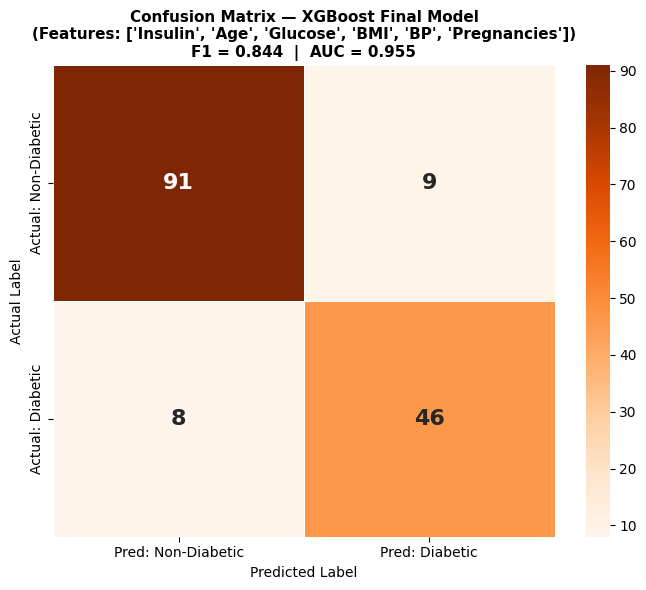

True Positives  (TP): 46  — Diabetic correctly identified
True Negatives  (TN): 91  — Healthy correctly identified
False Positives (FP): 9  — Healthy incorrectly flagged as Diabetic
False Negatives (FN): 8  — Diabetic MISSED (critical clinical error)

Sensitivity (Recall) : 0.8519
Specificity           : 0.9100


In [ ]:
# =============================================================================
# STAGE 13c — Confusion Matrix
# =============================================================================

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
tn_x, fp_x, fn_x, tp_x = cm_xgb.ravel()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Pred: Non-Diabetic', 'Pred: Diabetic'],
            yticklabels=['Actual: Non-Diabetic', 'Actual: Diabetic'],
            linewidths=0.5, annot_kws={'size': 16, 'weight': 'bold'})

plt.title(
    f'Confusion Matrix — XGBoost Final Model\n'
    f'(Features: {FINAL_FEATURES})\n'
    f'F1 = {f1_xgb:.3f}  |  AUC = {auc_xgb:.3f}',
    fontsize=11, fontweight='bold'
)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

print(f'True Positives  (TP): {tp_x}  — Diabetic correctly identified')
print(f'True Negatives  (TN): {tn_x}  — Healthy correctly identified')
print(f'False Positives (FP): {fp_x}  — Healthy incorrectly flagged as Diabetic')
print(f'False Negatives (FN): {fn_x}  — Diabetic MISSED (critical clinical error)')
print(f'\nSensitivity (Recall) : {tp_x/(tp_x+fn_x):.4f}')
print(f'Specificity           : {tn_x/(tn_x+fp_x):.4f}')

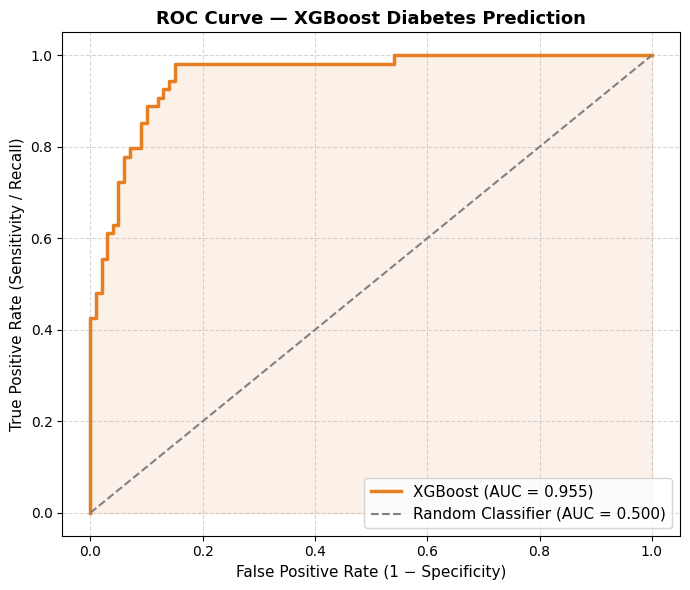

In [ ]:
# =============================================================================
# STAGE 13d — ROC Curve
# =============================================================================
# ROC curve visualises discrimination ability across ALL probability thresholds.
# AUC > 0.85 is considered strong for binary clinical classifiers.

fpr, tpr, thresholds = roc_curve(y_test, y_pred_xgb_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#e67e22', lw=2.5,
         label=f'XGBoost (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
         label='Random Classifier (AUC = 0.500)')
plt.fill_between(fpr, tpr, alpha=0.10, color='#e67e22')

plt.xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve — XGBoost Diabetes Prediction',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

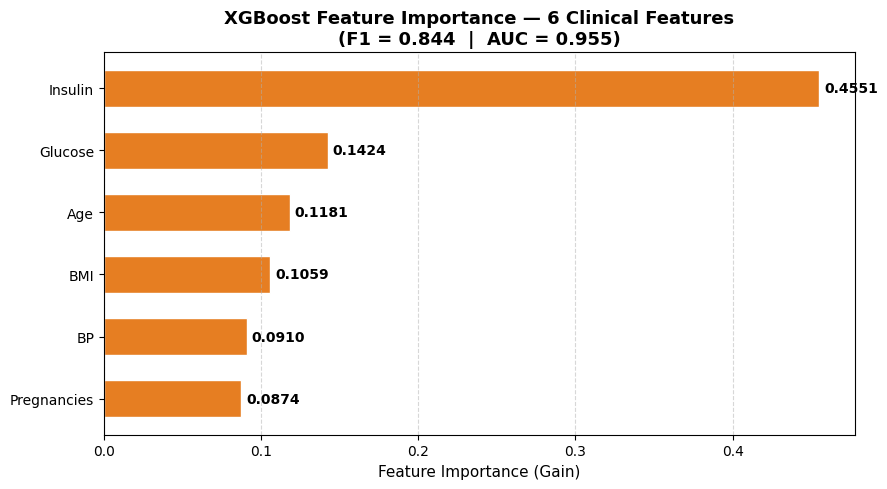

In [ ]:
# =============================================================================
# STAGE 13e — XGBoost Feature Importance (Gain)
# =============================================================================

xgb_importances = pd.DataFrame({
    'Feature':    FINAL_FEATURES,
    'Gain':       xgb_final.feature_importances_
}).sort_values('Gain', ascending=True)

plt.figure(figsize=(9, 5))
bars_xgb = plt.barh(xgb_importances['Feature'], xgb_importances['Gain'],
                    color='#e67e22', edgecolor='white', height=0.6)

for bar, val in zip(bars_xgb, xgb_importances['Gain']):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10, fontweight='bold')

plt.xlabel('Feature Importance (Gain)', fontsize=11)
plt.title(f'XGBoost Feature Importance — 6 Clinical Features\n'
          f'(F1 = {f1_xgb:.3f}  |  AUC = {auc_xgb:.3f})',
          fontsize=13, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

          MODEL COMPARISON SUMMARY
                         Model  Accuracy  F1 Score  ROC-AUC
Logistic Regression (Baseline)    0.7597    0.7040   0.8369
  Random Forest (All Features)    0.8766    0.8224   0.9570
    Random Forest (6 Clinical)    0.8766    0.8224   0.9484
        XGBoost — (6 Clinical)    0.8896    0.8440   0.9548
              SVM (6 Clinical)    0.8442    0.7931   0.8935


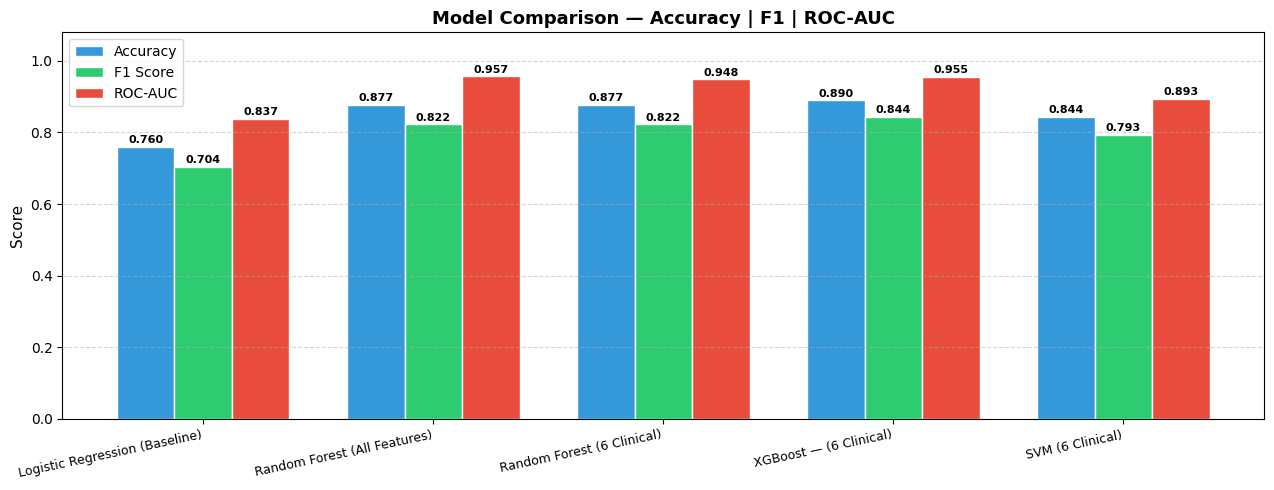

In [ ]:
# =============================================================================
# STAGE 13f — Model Comparison Dashboard
# =============================================================================

model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression (Baseline)',
        'Random Forest (All Features)',
        'Random Forest (6 Clinical)',
        'XGBoost — (6 Clinical)',
        'SVM (6 Clinical)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_curated),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_svm_final)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_curated),
        f1_score(y_test, y_pred_xgb),
        f1_score(y_test, y_pred_svm_final)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test_scaled)[:,1]),
        roc_auc_score(y_test, rf_curated.predict_proba(
            X_test_scaled[:, final_indices])[:,1]),
        roc_auc_score(y_test, y_pred_xgb_proba),
        roc_auc_score(y_test, svm_final.predict_proba(X_test_scaled[:, final_indices])[:,1])
    ]
}).round(4)

print('=' * 70)
print('          MODEL COMPARISON SUMMARY')
print('=' * 70)
print(model_comparison.to_string(index=False))

# ── Grouped Bar Chart ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))

x    = np.arange(len(model_comparison['Model']))
w    = 0.25
met  = ['Accuracy', 'F1 Score', 'ROC-AUC']
cols = ['#3498db', '#2ecc71', '#e74c3c']

for i, (metric, color) in enumerate(zip(met, cols)):
    bars_cmp = ax.bar(x + i*w, model_comparison[metric],
                      width=w, label=metric, color=color, edgecolor='white')
    for bar, val in zip(bars_cmp, model_comparison[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_xticks(x + w)
ax.set_xticklabels(model_comparison['Model'], rotation=12, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Model Comparison — Accuracy | F1 | ROC-AUC',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 1.08)
ax.legend(fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

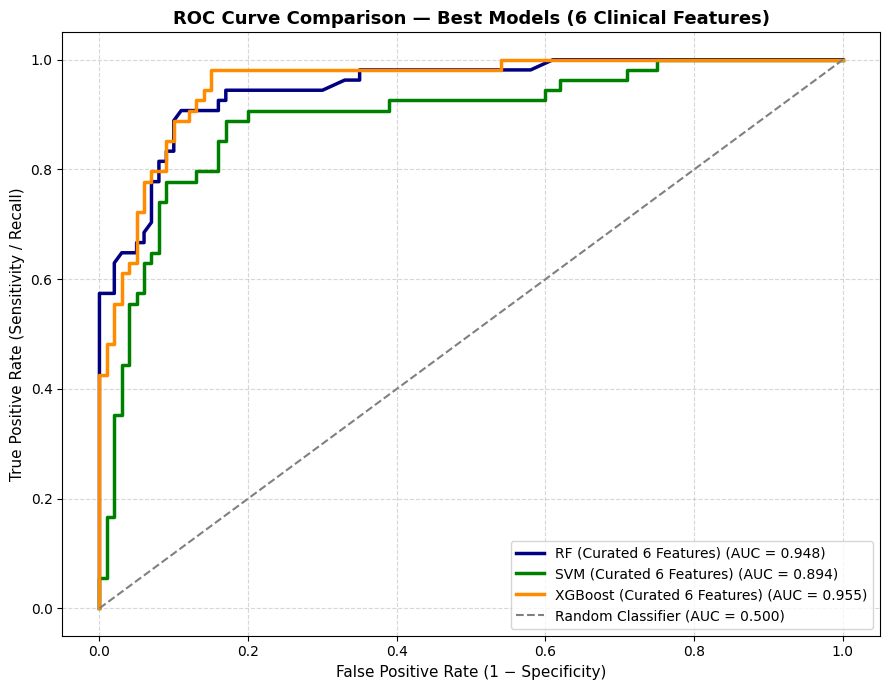

In [ ]:
# =============================================================================
# Comparative ROC Curve — RF, SVM, XGBoost (6 Clinical Features)
# =============================================================================

# Calculate ROC curve and AUC for RF (curated)
fpr_rf_curated, tpr_rf_curated, _ = roc_curve(y_test, y_pred_proba_rf_curated)
auc_rf_curated = roc_auc_score(y_test, y_pred_proba_rf_curated)

# Calculate ROC curve and AUC for SVM
y_pred_proba_svm_final = svm_final.predict_proba(X_test_scaled[:, final_indices])[:, 1]
fpr_svm_final, tpr_svm_final, _ = roc_curve(y_test, y_pred_proba_svm_final)
auc_svm_final = roc_auc_score(y_test, y_pred_proba_svm_final)

# Calculate ROC curve and AUC for XGBoost
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_pred_xgb_proba)
auc_xgb = roc_auc_score(y_test, y_pred_xgb_proba)

# Plotting the ROC Curves
plt.figure(figsize=(9, 7))
plt.plot(fpr_rf_curated, tpr_rf_curated, color='navy', lw=2.5,
         label=f'RF (Curated 6 Features) (AUC = {auc_rf_curated:.3f})')
plt.plot(fpr_svm_final, tpr_svm_final, color='green', lw=2.5,
         label=f'SVM (Curated 6 Features) (AUC = {auc_svm_final:.3f})')
plt.plot(fpr_xgb, tpr_xgb, color='darkorange', lw=2.5,
         label=f'XGBoost (Curated 6 Features) (AUC = {auc_xgb:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1.5,
         label='Random Classifier (AUC = 0.500)')

plt.xlabel('False Positive Rate (1 − Specificity)', fontsize=11)
plt.ylabel('True Positive Rate (Sensitivity / Recall)', fontsize=11)
plt.title('ROC Curve Comparison — Best Models (6 Clinical Features)',
          fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# FINAL MODEL CARD
# =============================================================================

cm_final = confusion_matrix(y_test, y_pred_xgb)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

print('=' * 62)
print('          DIABETES PREDICTION — FINAL MODEL CARD')
print('=' * 62)
print(f'  Algorithm         : XGBoost Classifier')
print(f'  Feature Set       : {FINAL_FEATURES}')
print(f'  Train Samples     : {len(X_train)} (80%)')
print(f'  Test  Samples     : {len(X_test)} (20%)')
print(f'  Split Strategy    : Stratified, BEFORE imputation')
print(f'  Imputation        : Class-conditional median (train-derived only)')
print()
print(f'  ── Test Set Performance ─────────────────────────────')
print(f'  Accuracy          : {acc_xgb:.4f}')
print(f'  F1 Score          : {f1_xgb:.4f}')
print(f'  ROC-AUC           : {auc_xgb:.4f}')
print(f'  Sensitivity       : {tp_f/(tp_f+fn_f):.4f}  (Diabetics correctly caught)')
print(f'  Specificity       : {tn_f/(tn_f+fp_f):.4f}  (Healthy correctly cleared)')
print(f'  False Negatives   : {fn_f}         (Missed diabetics — minimised)')
print()
print(f'  ── Hyperparameters ──────────────────────────────────')
for k, v in best_params.items():
    print(f'  {k:20s}: {v}')
print(f'  scale_pos_weight  : {SCALE_POS_WEIGHT:.2f} (class imbalance correction)')
print('=' * 62)

          DIABETES PREDICTION — FINAL MODEL CARD
  Algorithm         : XGBoost Classifier
  Feature Set       : ['Insulin', 'Age', 'Glucose', 'BMI', 'BP', 'Pregnancies']
  Train Samples     : 614 (80%)
  Test  Samples     : 154 (20%)
  Split Strategy    : Stratified, BEFORE imputation
  Imputation        : Class-conditional median (train-derived only)

  ── Test Set Performance ─────────────────────────────
  Accuracy          : 0.8896
  F1 Score          : 0.8440
  ROC-AUC           : 0.9548
  Sensitivity       : 0.8519  (Diabetics correctly caught)
  Specificity       : 0.9100  (Healthy correctly cleared)
  False Negatives   : 8         (Missed diabetics — minimised)

  ── Hyperparameters ──────────────────────────────────
  colsample_bytree    : 1.0
  learning_rate       : 0.05
  max_depth           : 4
  n_estimators        : 200
  subsample           : 0.8
  scale_pos_weight  : 1.87 (class imbalance correction)


---
## 📋 Complete Summary

| # | Stage | Steps | Technique | Justification |
|---|-------|-------|-----------|---------------|
| 1 | **Required Packages** | Install xgboost; import sklearn, pandas, matplotlib | Standard ML stack | Reproducible environment with fixed random seed |
| 2 | **Import Data & EDA** | Load CSV; class distribution; zero-count analysis; histograms by class; correlation heatmap | Descriptive stats, KDE histograms, heatmap | Reveals 65:35 imbalance, clinically impossible zeros encoding missing data, outliers (Insulin max=846), and feature correlations |
| 3 | **Train/Test Split** | 80:20 stratified split **before** any preprocessing | `train_test_split(stratify=y)` | Stratification preserves class ratio; splitting first is the gold standard to prevent leakage of test statistics into any preprocessing step |
| 4 | **Imputation + Shadow Vars** | (a) Shadow flags created pre-NaN (b) Zeros→NaN (c) Class-conditional medians from train only → applied to test | Class-conditional median imputation | Median robust to outliers. Class-conditional preserves biological difference (diabetic vs healthy baselines). No test data ever informs any statistic |
| 5 | **Logistic Regression** | Scale (train-fit only); train LR; predict; evaluate | `LogisticRegression(class_weight='balanced')` | Interpretable linear baseline; establishes minimum performance floor; coefficient signs are clinically readable |
| 6 | **LR Feature Importance** | Extract coefficients; horizontal bar chart; green/red by sign | Coefficient magnitude | Shows which features drive diabetes risk linearly; shadow variable coefficients reveal if missingness is predictive |
| 7 | **Random Forest (All)** | Train 100-tree RF; evaluate; Gini importance chart | `RandomForestClassifier(class_weight='balanced')` | Captures non-linear interactions (Age × Glucose); significantly reduces false negatives; Insulin emerges as top feature; shadow vars show as noise |
| 8 | **Stepwise Selection** | Progressive loop; CV F1 per feature; user-driven keep/skip | 5-fold CV F1 on RF | Clinician-in-the-loop: performance evidence guides feature curation rather than algorithmic black-box selection |
| 9 | **RF (6 Clinical Features)** | Train 300-tree RF on `['Insulin','Age','Glucose','BMI','BP', 'Pregnancies']`; importance chart | Gini impurity importance | Leaner, more interpretable model; reduced overfitting; clinically meaningful feature set |
| 10 | **Cross-Validation** | 5-fold stratified CV; mean ± std F1; fold-by-fold bar chart | `StratifiedKFold(n_splits=5)` | Confirms generalisation: stable CV scores across folds mean the model is not overfit to one lucky split |
| 11 | **SVM** |Trained SVM on selected features |'kernel='rbf', class_weight='balanced' ' |Lower False negatives |
| 11 | **Grid Search** | `GridSearchCV` on XGBoost; tune `n_estimators`, `max_depth`, `learning_rate`, `subsample`, `colsample_bytree`; F1 scoring | Exhaustive parameter search + 5-fold CV | Finds globally optimal hyperparameters without manual trial-and-error; F1 scoring keeps tuning aligned with the clinical objective (diabetic detection) |
| 12 | **XGBoost — Final Model** | Train with best params + `scale_pos_weight`; predict; full evaluation: accuracy, F1, AUC, confusion matrix, ROC curve, feature importance, model comparison dashboard | `XGBClassifier` — sequential boosting | XGBoost's boosting mechanism corrects prior errors, making it superior at reducing false negatives; built-in L1/L2 regularisation prevents overfitting; `scale_pos_weight` handles imbalance without synthetic oversampling |